In [85]:
!pip install gdown

In [1]:
gid_map = {
    'scalability': '1513474150',
    'optimality': '2117154112'
}

In [2]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats

sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"

def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.cached_download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df


def calculate_grouped_stats_and_ci(df: pd.DataFrame, 
                                   grouping_columns: list, 
                                   value_column: str, 
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for a given value column.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_column (str): The name of the column for which to calculate the mean,
                            count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns.
    """
    
    # Check if value_column is numeric
    if not pd.api.types.is_numeric_dtype(df[value_column]):
        raise TypeError(f"The '{value_column}' must be a numeric column.")

    # Group by the specified columns and aggregate mean, count, and std
    grouped_df = df.groupby(grouping_columns)[value_column].agg(['mean', 'count', 'std']).reset_index()
    grouped_df.rename(columns={'mean': 'Average', 'count': 'Count', 'std': 'Std_Dev'}, inplace=True)

    # Calculate alpha for confidence interval
    alpha = 1 - confidence_level

    # Function to calculate confidence interval for each group
    def calculate_ci_row(row):
        if row['Count'] < 2 or pd.isna(row['Std_Dev']):  # Need at least 2 points and a valid std_dev
            return np.nan, np.nan
        
        # Degrees of freedom for t-distribution
        df_t = row['Count'] - 1
        
        # Calculate standard error of the mean
        sem = row['Std_Dev'] / np.sqrt(row['Count'])
        
        # Calculate confidence interval
        lower, upper = stats.t.interval(confidence_level, df_t, loc=row['Average'], scale=sem)
        return lower, upper

    # Apply the function to each row to get the confidence interval
    grouped_df[['CI_Lower', 'CI_Upper']] = grouped_df.apply(
        lambda row: calculate_ci_row(row), axis=1, result_type='expand'
    )
    
    return grouped_df


In [3]:
optimality_df = get_pandas_from_gid('optimality')
optimality_df

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Cached downloading...
From: https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/export?format=csv&gid=2117154112
To: optimality.csv
1.12MB [00:00, 7.36MB/s]


,Key Agg,Graph Name,Initial Vertices,Initial Solutions,Timeout (ms),Objective Function,Threads,Repetition,Total Time (ms),Effective Runs,Cost Best Solution,Vertices,Edges,Best Solution
0,patents1010002000triangledensestsubgraph32,patents,10,1000,2000,triangledensestsubgraph,32,3,63523,975,1992.275000,120,4663,"vsub(nvertices=120,nedges=4663,vertices={27388..."
1,patents1010003000triangledensestsubgraph32,patents,10,1000,3000,triangledensestsubgraph,32,5,95173,965,1992.275000,120,4663,"vsub(nvertices=120,nedges=4663,vertices={27388..."
2,patents1010003000triangledensestsubgraph32,patents,10,1000,3000,triangledensestsubgraph,32,4,95087,975,1975.933884,121,4667,"vsub(nvertices=121,nedges=4667,vertices={27388..."
3,patents1010003000triangledensestsubgraph32,patents,10,1000,3000,triangledensestsubgraph,32,1,94989,975,1959.762295,122,4669,"vsub(nvertices=122,nedges=4669,vertices={27388..."
4,patents1010002000triangledensestsubgraph32,patents,10,1000,2000,triangledensestsubgraph,32,1,63635,973,1902.619048,126,4725,"vsub(nvertices=126,nedges=4725,vertices={27388..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,youtube101001000modularity32,youtube,10,100,1000,modularity,32,1,3419,92,0.001296,7513,56981,NaN
671,youtube101001000modularity32,youtube,10,100,1000,modularity,32,3,3450,90,0.001295,7731,56936,NaN
672,youtube101001000modularity32,youtube,10,100,1000,modularity,32,4,3424,86,0.001237,7276,54384,NaN
673,youtube101001000modularity32,youtube,10,100,1000,modularity,32,2,3517,91,0.001206,7564,53042,NaN


In [25]:
grouping_columns = ["Graph Name", "Objective Function", "Initial Vertices", "Initial Solutions", "Threads"]
value_column = "Cost Best Solution"
grouped_df = calculate_grouped_stats_and_ci(optimality_df, grouping_columns, value_column)
grouped_df

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,Graph Name,Objective Function,Initial Vertices,Initial Solutions,Threads,Average,Count,Std_Dev,CI_Lower,CI_Upper
0,citeseer,conductance,10,10,32,0.995744,15,0.006760,0.992001,0.999488
1,citeseer,conductance,10,100,32,0.993018,15,0.007643,0.988785,0.997250
2,citeseer,conductance,10,1000,32,1.000000,15,0.000000,NaN,NaN
3,citeseer,densesubgraph,10,10,32,4.816327,15,0.000000,NaN,NaN
4,citeseer,densesubgraph,10,100,32,4.909091,15,0.000000,NaN,NaN
5,citeseer,densesubgraph,10,1000,32,4.909091,15,0.000000,NaN,NaN
6,citeseer,densitymass,10,10,32,1.000000,15,0.000000,NaN,NaN
7,citeseer,densitymass,10,100,32,1.000000,15,0.000000,NaN,NaN
8,citeseer,densitymass,10,1000,32,1.000000,15,0.000000,NaN,NaN
9,citeseer,modularity,10,10,32,0.238274,15,0.001027,0.237705,0.238843


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_average_by_group_and_initial_solutions(df: pd.DataFrame, grouping_columns: list):
    """
    Generates a Matplotlib bar plot showing 'Average' performance with confidence intervals
    as error bars. The x-axis represents combined experimental groups, and 'Initial Solutions'
    is used for the legend (differentiating bars within each group).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'Graph Name', 'Objective Function',
                           'Initial Vertices', 'Timeout (ms)', 'Threads',
                           'Initial Solutions', 'Average', 'CI_Lower', 'CI_Upper'.
        grouping_columns (list): A list of column names that define the unique
                                 experimental groups for the X-axis (excluding 'Initial Solutions').
    """

    # Ensure necessary columns are numeric
    #df['Average'] = pd.to_numeric(df['Average'], errors='coerce')
    #df['Initial Solutions'] = pd.to_numeric(df['Initial Solutions'], errors='coerce')
    #df['CI_Lower'] = pd.to_numeric(df['CI_Lower'], errors='coerce')
    #df['CI_Upper'] = pd.to_numeric(df['CI_Upper'], errors='coerce')
#
    ## Drop rows where critical plotting data is missing
    #df.dropna(subset=['Average', 'Initial Solutions', 'CI_Lower', 'CI_Upper'], inplace=True)

    # Sort for consistent plotting: first by grouping_columns, then by Initial Solutions
    df = df.sort_values(by=grouping_columns + ['Initial Solutions'])

    plt.figure(figsize=(18, 9)) # Adjust figure size for potentially more x-axis labels

    # Get unique 'Initial Solutions' for legend and bar differentiation
    unique_initial_solutions = sorted(df['Initial Solutions'].unique())
    num_initial_solutions = len(unique_initial_solutions)

    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{col}: {row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.8 / num_initial_solutions if num_initial_solutions > 0 else 0.8
    
    # Generate a distinct color for each 'Initial Solution' value
    colors = plt.cm.get_cmap('viridis', num_initial_solutions)
    
    # Iterate through each unique 'Initial Solution' value to plot its bars
    for i, solution_count in enumerate(unique_initial_solutions):
        # Filter data for the current 'Initial Solution' count
        subset_df = df[df['Initial Solutions'] == solution_count].copy()
        
        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')
        
        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this 'Initial Solution' count
        offset = (i - num_initial_solutions / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        
        # Calculate error bars
        yerr_lower = subset_df['Average'] - subset_df['CI_Lower']
        yerr_upper = subset_df['CI_Upper'] - subset_df['Average']

        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df['Average'],
            yerr=[yerr_lower, yerr_upper],
            width=bar_width,
            capsize=5,
            label=f'Initial Solutions: {int(solution_count)}', # Label for the legend
            color=colors(i),
            edgecolor='black',
            linewidth=0.8,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )

    plt.xlabel('Experimental Group Configuration', fontsize=15) # X-axis label with group name
    plt.ylabel('Average Score', fontsize=15)
    
    plt.xticks(x_axis_positions, unique_groups, rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=13)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for initial solutions
    plt.legend(title="Number of Initial Solutions", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=11, title_fontsize=13)
    
    plt.tight_layout(rect=[0, 0, 0.78, 1])
    plt.show()

/tmp/ipykernel_34068/2798090954.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', num_initial_solutions)


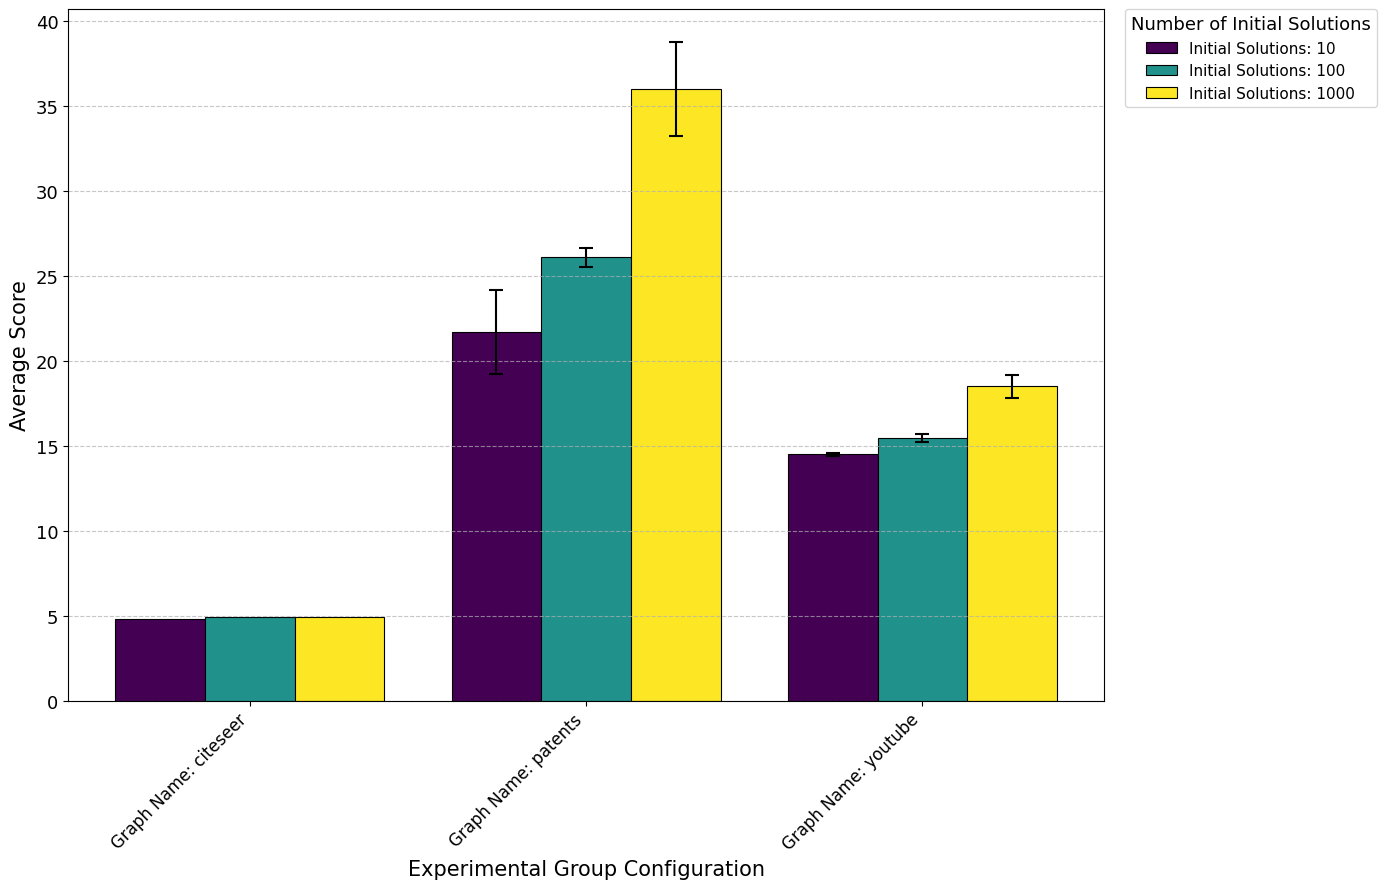

In [33]:
grouping_cols = ["Graph Name"]
df = grouped_df[grouped_df["Objective Function"] == "densesubgraph"]
plot_average_by_group_and_initial_solutions(df, grouping_cols)

/tmp/ipykernel_34068/2798090954.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', num_initial_solutions)


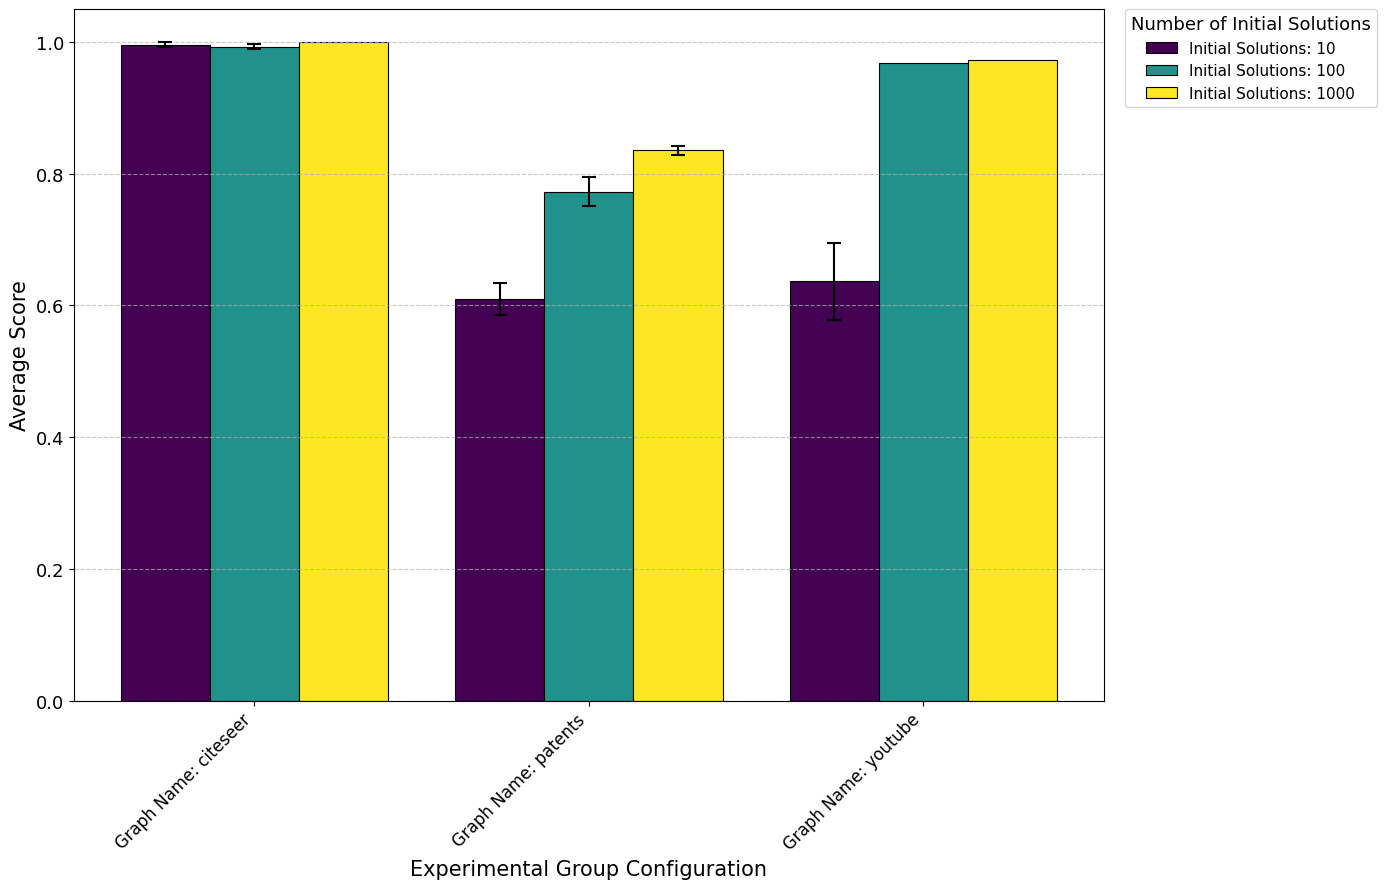

In [34]:
grouping_cols = ["Graph Name"]
df = grouped_df[grouped_df["Objective Function"] == "conductance"]
plot_average_by_group_and_initial_solutions(df, grouping_cols)

/tmp/ipykernel_34068/2798090954.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', num_initial_solutions)


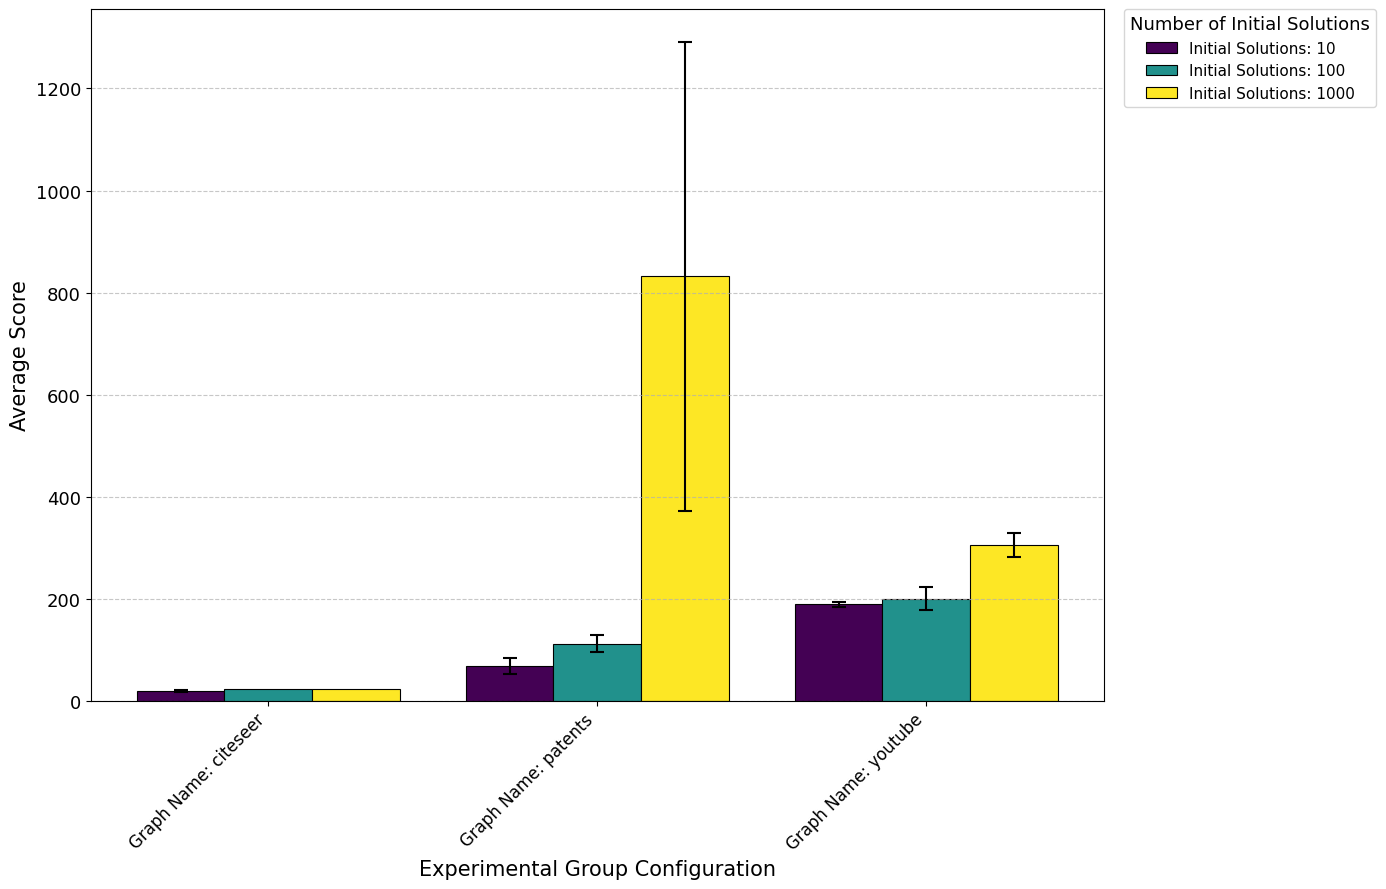

In [35]:
grouping_cols = ["Graph Name"]
df = grouped_df[grouped_df["Objective Function"] == "triangledensestsubgraph"]
plot_average_by_group_and_initial_solutions(df, grouping_cols)